# C-Phase · Conclude and Compare

Finales Modell quantitativ, qualitativ und gegen Erfolgskriterien bewerten.

**Projekt:** MietCheck · Big Data & Data Analytics · QUA³CK

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

COLORS = {"navy": "#14213D", "blue": "#2563EB", "teal": "#0F766E",
          "amber": "#F59E0B", "red": "#DC2626", "grey": "#64748B"}
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (9, 4.8), "axes.titleweight": "bold",
                     "axes.labelsize": 10, "figure.dpi": 110})

def load_json(relative_path):
    return json.loads((ROOT / relative_path).read_text(encoding="utf-8"))

print(f"Projektwurzel: {ROOT}")

Projektwurzel: C:\Users\nelek\Desktop\Big Data\MietCheck


## 1. Vergleich der A-Phasen

A¹ wählt HGB aus sieben Kandidaten, A² prüft den Zusatznutzen der Feature-Gruppen und A³ optimiert acht HGB-Konfigurationen. Erst danach wird das Modell auf allen Entwicklungsblöcken trainiert. Kalibrierung und finaler Test bleiben räumlich disjunkt.

In [2]:
final = load_json("reports/final_model_evaluation.json")
partition = pd.DataFrame([
    (name, details["rows"], details["blocks"], details["group_sha256"][:12])
    for name, details in final["partition"].items()
], columns=["Partition", "Zeilen", "25-km-Blöcke", "Gruppen-Hash"])
display(partition.style.hide(axis="index"))
assert partition["25-km-Blöcke"].sum() == 663
assert partition["Gruppen-Hash"].nunique() == 3

Partition,Zeilen,25-km-Blöcke,Gruppen-Hash
calibration,263789,99,d1fe0f764572
test,276458,99,7da06f24d239
development,1518322,465,efab4dce9c55


## 2. Formale KPI-Validierung auf dem unangetasteten Test

In [3]:
point = final["test"]["point_metrics"]
baseline = final["test"]["category_median_baseline_metrics"]
interval = final["test"]["category_specific_90_percent_interval"]
kpis = pd.DataFrame([
    ("MAE", point["mae"], "€/m²", "kleiner besser"),
    ("MedianAE", point["median_ae"], "€/m²", "robuster typischer Fehler"),
    ("RMSE", point["rmse"], "€/m²", "bestraft große Fehler"),
    ("R²", point["r2"], "", "erklärte Varianz"),
    ("Baseline-MAE", baseline["mae"], "€/m²", "fachlicher Mindestvergleich"),
    ("MAE-Verbesserung", final["test"]["mae_improvement_vs_baseline"], "%", "Go ≥ 15 %"),
    ("Intervall-Coverage", interval["coverage"], "%", "nominal 90 %"),
], columns=["KPI", "Wert", "Einheit", "Interpretation"])
display(kpis.style.hide(axis="index").format({"Wert": "{:.3f}"}))

KPI,Wert,Einheit,Interpretation
MAE,1.413,€/m²,kleiner besser
MedianAE,0.956,€/m²,robuster typischer Fehler
RMSE,2.130,€/m²,bestraft große Fehler
R²,0.584,,erklärte Varianz
Baseline-MAE,2.292,€/m²,fachlicher Mindestvergleich
MAE-Verbesserung,0.383,%,Go ≥ 15 %
Intervall-Coverage,0.868,%,nominal 90 %


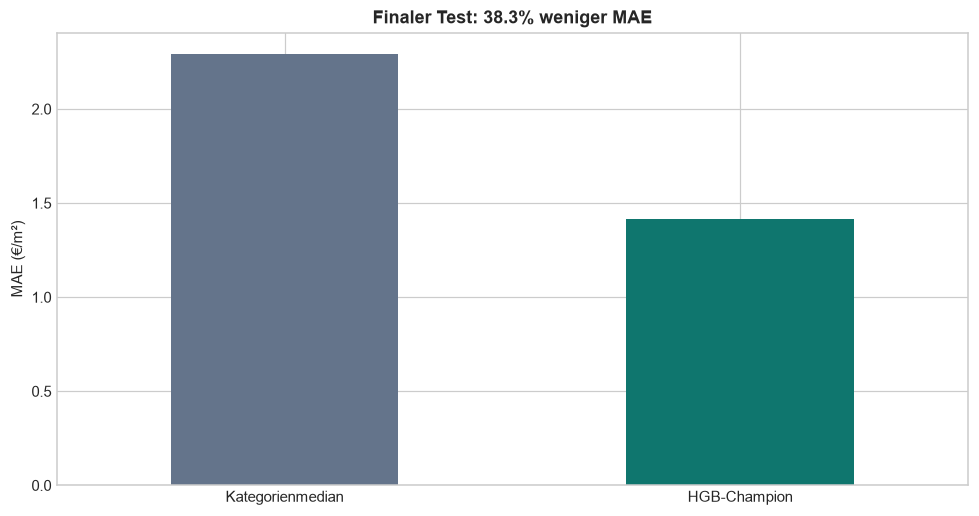

In [4]:
comparison = pd.DataFrame({
    "Modell": ["Kategorienmedian", "HGB-Champion"],
    "Test-MAE": [baseline["mae"], point["mae"]],
})
ax = comparison.plot.bar(x="Modell", y="Test-MAE",
                         color=[COLORS["grey"], COLORS["teal"]], legend=False)
ax.set(title=f"Finaler Test: {final['test']['mae_improvement_vs_baseline']:.1%} weniger MAE",
       ylabel="MAE (€/m²)", xlabel="")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

## 3. Unsicherheit mit Split Conformal Prediction

Absolute Residuen der **separaten Kalibrierungsblöcke** bestimmen kategoriespezifische 90-%-Bänder. Auf unbekannten Testregionen werden empirisch 86,8 % abgedeckt. Diese Unterdeckung gegenüber nominal 90 % wird als räumlicher Distribution Shift dokumentiert und nicht schöngerechnet.

In [5]:
subgroups = final["test"]["subgroups"]
subgroup_df = pd.DataFrame([
    {
        "Gruppe": name,
        "Zeilen": details["rows"],
        "MAE": details["point_metrics"]["mae"],
        "R²": details["point_metrics"]["r2"],
        "Coverage": details["interval_metrics"]["coverage"],
        "Bandbreite": details["interval_metrics"]["mean_width_eur_sqm"],
    }
    for name, details in subgroups.items()
])
display(subgroup_df.round(3).style.hide(axis="index"))

Gruppe,Zeilen,MAE,R²,Coverage,Bandbreite
official_target_certain,244888,1.414000,0.570000,0.868000,5.472000
official_target_uncertain,31570,1.405000,0.181000,0.872000,5.390000
category_0_0,81662,1.436000,0.547000,0.874000,5.753000
category_0_1,114791,1.170000,0.603000,0.876000,4.636000
category_1_0,29417,1.907000,0.487000,0.852000,6.954000
category_1_1,50588,1.642000,0.550000,0.851000,6.003000


## 4. Qualitative Bewertungsmatrix

| Kriterium | HGB | Random Forest | LinearSVR/RBF | Einzelbaum |
|---|---:|---:|---:|---:|
| räumlicher CV-MAE | sehr gut | sehr gut | schwächer | mittel |
| Skalierbarkeit auf 2,06 Mio. | sehr gut | gut | linear gut / RBF schwach | sehr gut |
| Artefakt/Inference | sehr gut | mittel | gut / schwach | sehr gut |
| nichtlineare Interaktionen | sehr gut | sehr gut | kernelabhängig | begrenzt |
| Transparenz | mittel | mittel | mittel | hoch |

Die Wahl von HGB basiert damit nicht nur auf MAE, sondern auf Generalisierung, Rechenaufwand und Deployment-Tauglichkeit.

## 5. Feature-Wirkung und Plausibilität

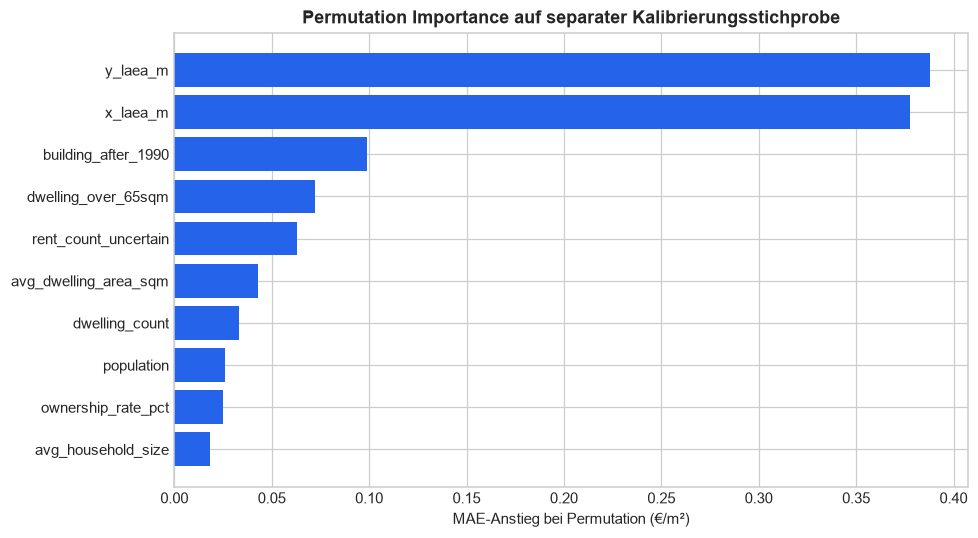

In [6]:
importance = pd.DataFrame(
    final["permutation_importance_on_calibration_sample"]["results"]
).head(10).sort_values("mae_increase_mean")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(importance["feature"], importance["mae_increase_mean"], color=COLORS["blue"])
ax.set(title="Permutation Importance auf separater Kalibrierungsstichprobe",
       xlabel="MAE-Anstieg bei Permutation (€/m²)", ylabel="")
plt.tight_layout(); plt.show()

Koordinaten dominieren, was zur bekannten räumlichen Mietstruktur passt. Wichtig: Permutation Importance ist keine Kausalitätsanalyse. Sie zeigt Modellabhängigkeit unter korrelierten Merkmalen, nicht den Effekt politischer oder individueller Maßnahmen.

## 6. Finale Entscheidung und Grenzen

Alle vorab definierten Gates sind erfüllt: Big Data, räumlich disjunkte Splits, sieben Hauptkandidaten, >15 % Baseline-Verbesserung, separates Kalibrierungsset und reproduzierbare Artefakte. Der HGB-Champion wird deshalb an K übergeben.

**Grenzen:** keine Ausstattung, Energieklasse, Etage oder adressgenaue Mikrolage; Zensus-Stichtag 2022; GREIX nur für abgedeckte Märkte; empirische Coverage unter nominal 90 %; keine Rechtsberatung und kein amtlicher Mietspiegel.

In [7]:
decision = {
    "Champion": final["model"]["type"],
    "Test-MAE": round(point["mae"], 3),
    "Verbesserung vs. Baseline": f"{final['test']['mae_improvement_vs_baseline']:.1%}",
    "Coverage": f"{interval['coverage']:.1%}",
    "Freigabe an K": (
        final["test"]["mae_improvement_vs_baseline"] >= .15
        and final["partition"]["test"]["blocks"] > 0
    ),
}
display(pd.Series(decision).to_frame("Entscheidung"))

,Entscheidung
Champion,HistGradientBoostingRegressor
Test-MAE,1.413
Verbesserung vs. Baseline,38.3%
Coverage,86.8%
Freigabe an K,True


---

**Reproduzierbarkeit:** Kennzahlen stammen aus versionierten JSON-/CSV-Artefakten. Die genannten Skripte erzeugen sie aus den öffentlichen Rohdaten erneut. Schwere Trainingsläufe liegen bewusst in getesteten Skripten, damit Notebook und produktive Pipeline dieselben Splits, Parameter und Reports verwenden.